## Hijerarhijsko klasterovanje

In [1]:
import pandas as pd
from numpy.ma.extras import unique

In [4]:
data = pd.read_csv('./data/dogs.csv')
data

,breed,height,weight
0,Border Collie,20,45
1,Boston Terrier,16,20
2,Brittany Spaniel,18,35
3,Bullmastiff,27,120
4,Chihuahua,8,8
5,German Shepherd,25,78
6,Golden Retriever,23,70
7,Great Dane,32,160
8,Portuguese Water Dog,21,50
9,Standard Poodle,19,65


In [7]:
from sklearn.preprocessing import MinMaxScaler

In [9]:
scaler = MinMaxScaler()

In [15]:
X = data[data.columns[1:]]

In [16]:
x_scaled = scaler.fit_transform(X)

In [18]:
x_scaled = pd.DataFrame(x_scaled, columns=data.columns[1:])
x_scaled

,height,weight
0,0.538462,0.248366
1,0.384615,0.084967
2,0.461538,0.183007
3,0.807692,0.738562
4,0.076923,0.006536
5,0.730769,0.464052
6,0.653846,0.411765
7,1.000000,1.000000
8,0.576923,0.281046
9,0.500000,0.379085


In [19]:
from sklearn.cluster import AgglomerativeClustering

In [26]:
model = AgglomerativeClustering(n_clusters=3, linkage='average')

In [30]:
from sklearn.metrics import silhouette_score

In [27]:
model.fit(x_scaled)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'average'
,distance_threshold,None
,compute_distances,False


In [31]:
silhouette_score(x_scaled,model.labels_)

0.5813924452451538

In [25]:
model.labels_

array([0, 0, 0, 1, 2, 0, 0, 1, 0, 0, 2])

In [29]:
model.children_

array([[ 0,  8],
       [ 4, 10],
       [ 5,  6],
       [ 1,  2],
       [ 9, 11],
       [14, 15],
       [13, 16],
       [ 3,  7],
       [12, 17],
       [18, 19]])

In [32]:
from matplotlib import pyplot as plt

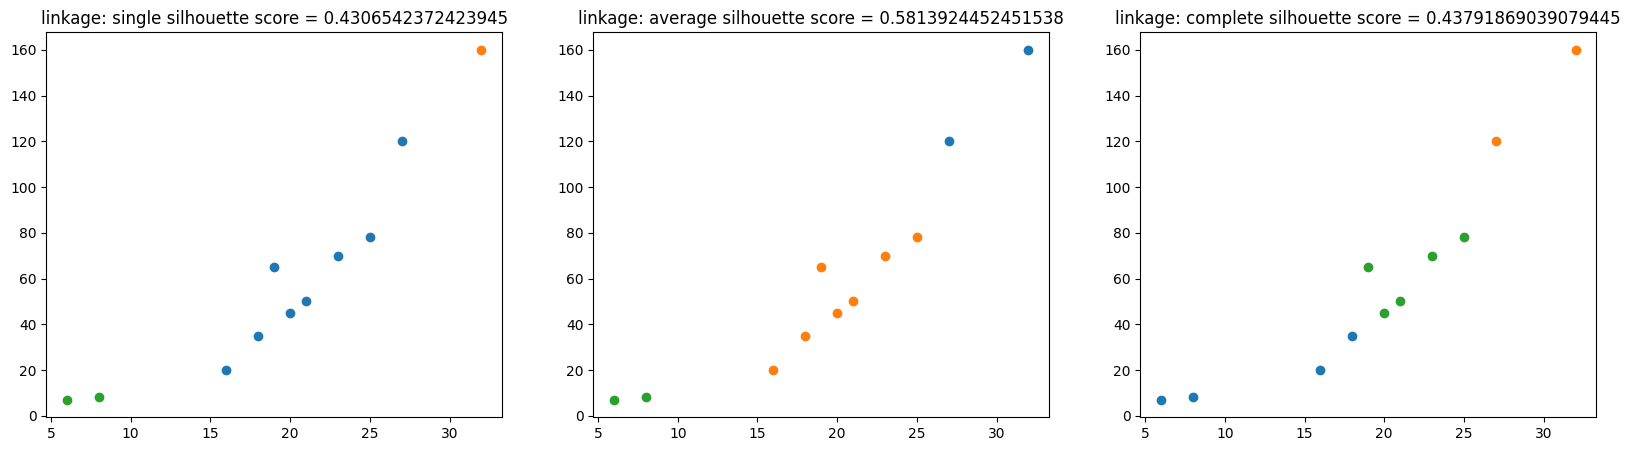

In [41]:
k = 3
linkages = ['single', 'average', 'complete']
siluetes = []

fig = plt.figure(figsize=(20, 5))
idx = 1
for link in linkages:
    model = AgglomerativeClustering(n_clusters=k, linkage=link)
    model.fit(x_scaled)

    siluetes.append(silhouette_score(x_scaled,model.labels_))

    fig.add_subplot(1, len(linkages), idx)
    idx += 1
    for cluster_label in range(k):
        cluster = data[cluster_label == model.labels_]
        plt.scatter(cluster['height'],cluster['weight'], label=f'cluster:{cluster_label}')
    plt.title(f'linkage: {link} silhouette score = {silhouette_score(x_scaled,model.labels_)}')


In [43]:
from sklearn.cluster import DBSCAN

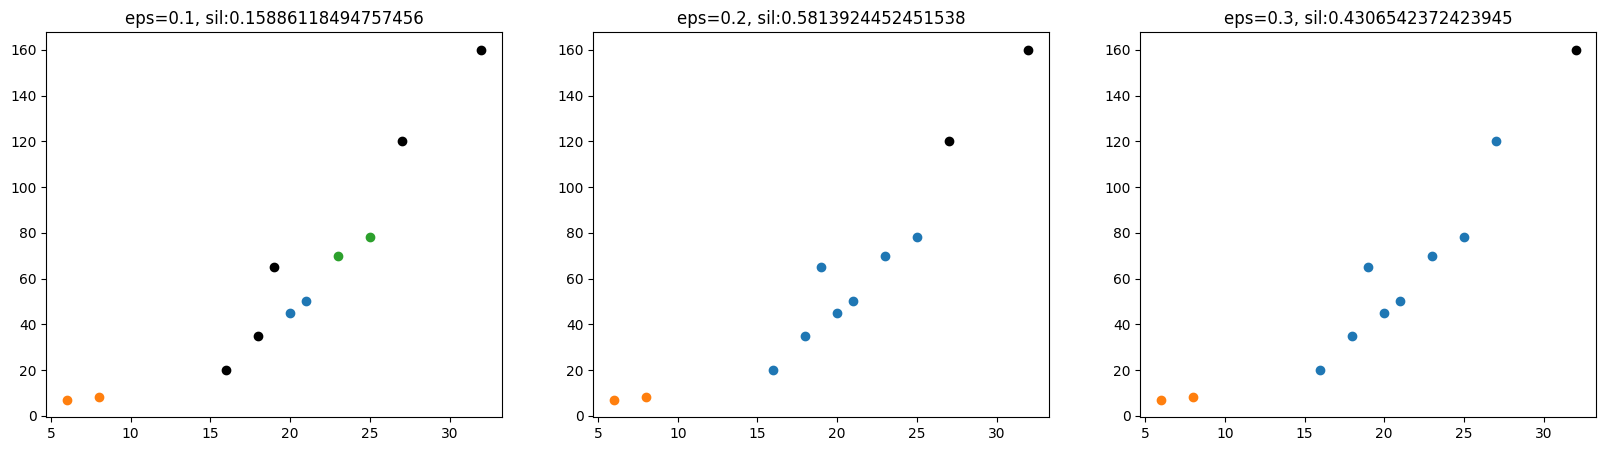

In [47]:
epss = [0.1, 0.2, 0.3]
min_neighbours = 2
fig = plt.figure(figsize=(20, 5))
for idx,eps in enumerate(epss):
    model = DBSCAN(eps=eps, min_samples=min_neighbours)
    model.fit(x_scaled)

    fig.add_subplot(1, len(epss), idx+1)
    k = max(model.labels_) + 1
    for cluster_class in range(-1, k): # sum dobijes kao -1
        cluster = data[cluster_class == model.labels_]
        if cluster_class == -1:
            plt.scatter(cluster['height'], cluster['weight'], label=f'sum:{cluster_class}', color='black')
        else:
            plt.scatter(cluster['height'], cluster['weight'], label=f'cluster:{cluster_class}')
        plt.title(f'eps={eps}, sil:{silhouette_score(x_scaled,model.labels_)}')
plt.show()